In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler,OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv('REAL TIME AIR QUALITY FROM VARIOUS LOCATION IN INDIA.csv')

In [3]:
data

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Bihar,Muzaffarpur,"MIT-Daudpur Kothi, Muzaffarpur - BSPCB",11-02-2026 21:00:00,26.140335,85.365019,NO2,2.0,4.0,3.0
1,India,Bihar,Muzaffarpur,"MIT-Daudpur Kothi, Muzaffarpur - BSPCB",11-02-2026 21:00:00,26.140335,85.365019,OZONE,11.0,72.0,50.0
2,India,Bihar,Muzaffarpur,"Muzaffarpur Collectorate, Muzaffarpur - BSPCB",11-02-2026 21:00:00,26.120900,85.364700,SO2,6.0,9.0,7.0
3,India,Bihar,Muzaffarpur,"Muzaffarpur Collectorate, Muzaffarpur - BSPCB",11-02-2026 21:00:00,26.120900,85.364700,CO,28.0,82.0,47.0
4,India,Bihar,Patna,"DRM Office Danapur, Patna - BSPCB",11-02-2026 21:00:00,25.586562,85.043586,NO2,48.0,56.0,51.0
...,...,...,...,...,...,...,...,...,...,...,...
3317,India,West_Bengal,Durgapur,"PCBL Residential Complex, Durgapur - WBPCB",11-02-2026 21:00:00,23.508764,87.354440,PM10,78.0,207.0,120.0
3318,India,West_Bengal,Kolkata,"Victoria, Kolkata - WBPCB",11-02-2026 21:00:00,22.544808,88.340369,PM10,100.0,244.0,158.0
3319,India,West_Bengal,Kolkata,"Victoria, Kolkata - WBPCB",11-02-2026 21:00:00,22.544808,88.340369,NO2,34.0,109.0,53.0
3320,India,West_Bengal,Kolkata,"Victoria, Kolkata - WBPCB",11-02-2026 21:00:00,22.544808,88.340369,NH3,8.0,9.0,8.0


In [4]:
data.shape

(3322, 11)

In [5]:
data.columns

Index(['country', 'state', 'city', 'station', 'last_update', 'latitude',
       'longitude', 'pollutant_id', 'pollutant_min', 'pollutant_max',
       'pollutant_avg'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3322 entries, 0 to 3321
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        3322 non-null   object 
 1   state          3322 non-null   object 
 2   city           3322 non-null   object 
 3   station        3322 non-null   object 
 4   last_update    3322 non-null   object 
 5   latitude       3322 non-null   float64
 6   longitude      3322 non-null   float64
 7   pollutant_id   3322 non-null   object 
 8   pollutant_min  3122 non-null   float64
 9   pollutant_max  3122 non-null   float64
 10  pollutant_avg  3122 non-null   float64
dtypes: float64(5), object(6)
memory usage: 285.6+ KB


In [7]:
data.describe()

,latitude,longitude,pollutant_min,pollutant_max,pollutant_avg
count,3322.000000,3322.000000,3122.000000,3122.000000,3122.000000
mean,23.033787,78.593634,29.818065,96.141896,58.470852
std,5.228564,4.898745,32.154738,106.226907,63.607334
min,8.514909,70.776774,1.000000,1.000000,1.000000
25%,19.174139,75.481275,6.000000,19.000000,13.000000
50%,23.555190,77.302523,17.000000,62.000000,36.000000
75%,27.215415,80.699436,44.000000,127.000000,84.000000
max,34.066206,94.636574,214.000000,500.000000,396.000000


In [8]:
data['state'].unique()

array(['Bihar', 'Assam', 'Andhra_Pradesh', 'Andaman and Nicobar', 'Delhi',
       'Chhattisgarh', 'Chandigarh', 'Gujarat', 'Haryana', 'Karnataka',
       'Kerala', 'Madhya Pradesh', 'Himachal Pradesh', 'Jharkhand',
       'Maharashtra', 'Odisha', 'Puducherry', 'Punjab', 'Meghalaya',
       'Mizoram', 'Rajasthan', 'Nagaland', 'TamilNadu', 'Sikkim',
       'Uttar_Pradesh', 'Telangana', 'Tripura', 'Uttarakhand',
       'West_Bengal', 'Arunachal_Pradesh', 'Jammu_and_Kashmir'],
      dtype=object)

In [9]:
data['pollutant_id'].unique()

array(['NO2', 'OZONE', 'SO2', 'CO', 'PM2.5', 'NH3', 'PM10'], dtype=object)

In [10]:
print(data['pollutant_avg'].describe())

count    3122.000000
mean       58.470852
std        63.607334
min         1.000000
25%        13.000000
50%        36.000000
75%        84.000000
max       396.000000
Name: pollutant_avg, dtype: float64


In [11]:
data['country'].unique()

array(['India'], dtype=object)

In [12]:
data['state'].unique()

array(['Bihar', 'Assam', 'Andhra_Pradesh', 'Andaman and Nicobar', 'Delhi',
       'Chhattisgarh', 'Chandigarh', 'Gujarat', 'Haryana', 'Karnataka',
       'Kerala', 'Madhya Pradesh', 'Himachal Pradesh', 'Jharkhand',
       'Maharashtra', 'Odisha', 'Puducherry', 'Punjab', 'Meghalaya',
       'Mizoram', 'Rajasthan', 'Nagaland', 'TamilNadu', 'Sikkim',
       'Uttar_Pradesh', 'Telangana', 'Tripura', 'Uttarakhand',
       'West_Bengal', 'Arunachal_Pradesh', 'Jammu_and_Kashmir'],
      dtype=object)

# ADDING AQI (AIR QUALITY INDEX)¶

In [13]:
# AQI in India standard:

#AQI	    Category        Likely health impact    
#0–50	     Good            Minimal impact on health. Air quality is satisfactory.
#51–100	     Satisfactory    Minor breathing discomfort for sensitive people (asthma, lung disease).
#101–200	 Moderate        Breathing discomfort for people with lung, asthma & heart diseases.
#201–300	 Poor            Breathing discomfort to most on prolonged exposure. Serious for people with heart/lung disease.
#301–400	 Very Poor       Respiratory illness on prolonged exposure. Affects even healthy individuals.
#401–500	 Severe          Severe health impact. Affects healthy people; serious effects for those with existing disease. May cause premature death.

In [14]:
def aqi_category(value):
    if value <= 50:
        return "Good"
    elif value <= 100:
        return "Satisfactory"
    elif value <= 200:
        return "Moderate"
    else:
        return "Poor"

data['aqi_category'] = data['pollutant_avg'].apply(aqi_category)

# Step 3 → Check
print("\naqi_category value counts:")
print(data['aqi_category'].value_counts())
print("\nShape:", data.shape)


aqi_category value counts:
aqi_category
Good            1860
Satisfactory     658
Moderate         466
Poor             338
Name: count, dtype: int64

Shape: (3322, 12)


In [15]:
print(data['pollutant_avg'].describe())
print(data[data['pollutant_avg'] > 200].shape)

count    3122.000000
mean       58.470852
std        63.607334
min         1.000000
25%        13.000000
50%        36.000000
75%        84.000000
max       396.000000
Name: pollutant_avg, dtype: float64
(138, 12)


In [16]:
data

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg,aqi_category
0,India,Bihar,Muzaffarpur,"MIT-Daudpur Kothi, Muzaffarpur - BSPCB",11-02-2026 21:00:00,26.140335,85.365019,NO2,2.0,4.0,3.0,Good
1,India,Bihar,Muzaffarpur,"MIT-Daudpur Kothi, Muzaffarpur - BSPCB",11-02-2026 21:00:00,26.140335,85.365019,OZONE,11.0,72.0,50.0,Good
2,India,Bihar,Muzaffarpur,"Muzaffarpur Collectorate, Muzaffarpur - BSPCB",11-02-2026 21:00:00,26.120900,85.364700,SO2,6.0,9.0,7.0,Good
3,India,Bihar,Muzaffarpur,"Muzaffarpur Collectorate, Muzaffarpur - BSPCB",11-02-2026 21:00:00,26.120900,85.364700,CO,28.0,82.0,47.0,Good
4,India,Bihar,Patna,"DRM Office Danapur, Patna - BSPCB",11-02-2026 21:00:00,25.586562,85.043586,NO2,48.0,56.0,51.0,Satisfactory
...,...,...,...,...,...,...,...,...,...,...,...,...
3317,India,West_Bengal,Durgapur,"PCBL Residential Complex, Durgapur - WBPCB",11-02-2026 21:00:00,23.508764,87.354440,PM10,78.0,207.0,120.0,Moderate
3318,India,West_Bengal,Kolkata,"Victoria, Kolkata - WBPCB",11-02-2026 21:00:00,22.544808,88.340369,PM10,100.0,244.0,158.0,Moderate
3319,India,West_Bengal,Kolkata,"Victoria, Kolkata - WBPCB",11-02-2026 21:00:00,22.544808,88.340369,NO2,34.0,109.0,53.0,Satisfactory
3320,India,West_Bengal,Kolkata,"Victoria, Kolkata - WBPCB",11-02-2026 21:00:00,22.544808,88.340369,NH3,8.0,9.0,8.0,Good


# EDA (EXPLOITARY DATA ANALYSIS)

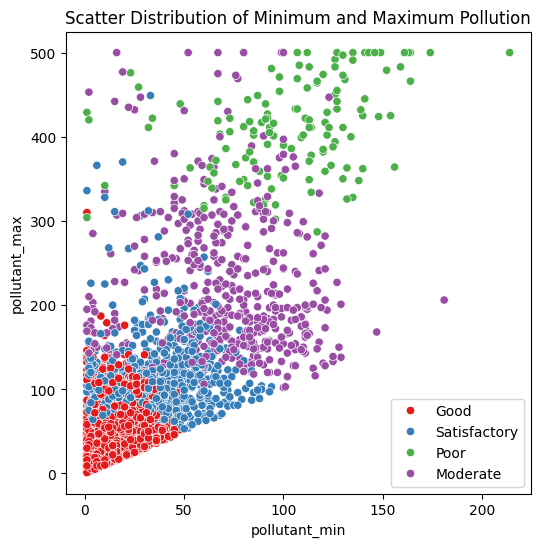

In [17]:
plt.figure(figsize=(6,6))
sns.scatterplot(data=data,x=data['pollutant_min'],y=data['pollutant_max'],hue=data['aqi_category'],palette="Set1")
plt.title("Scatter Distribution of Minimum and Maximum Pollution")
plt.legend()
plt.show()

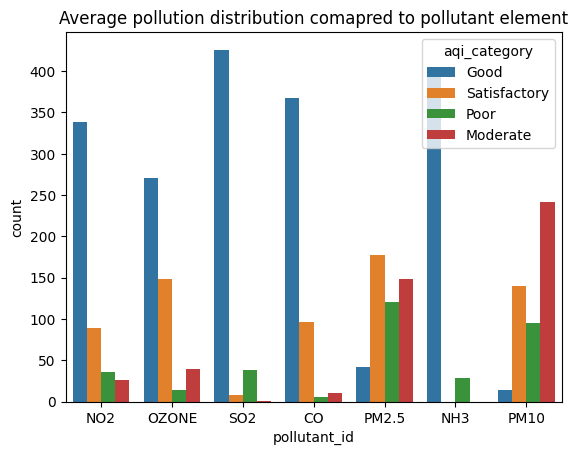

In [18]:
sns.countplot(data=data,x=data['pollutant_id'],hue='aqi_category')
plt.title('Average pollution distribution comapred to pollutant element')
plt.show()

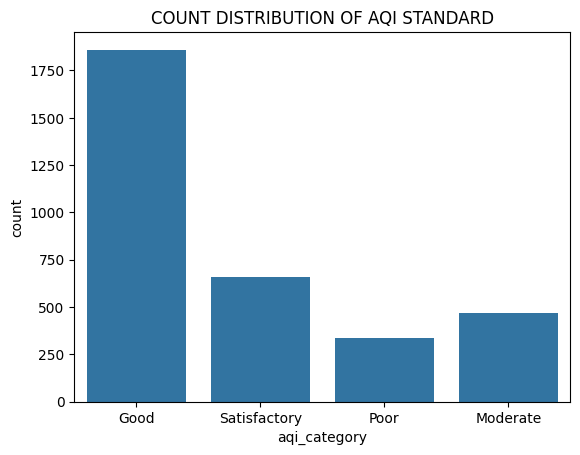

In [19]:
sns.countplot(data=data,x=data['aqi_category'])
plt.title("COUNT DISTRIBUTION OF AQI STANDARD")
plt.show()

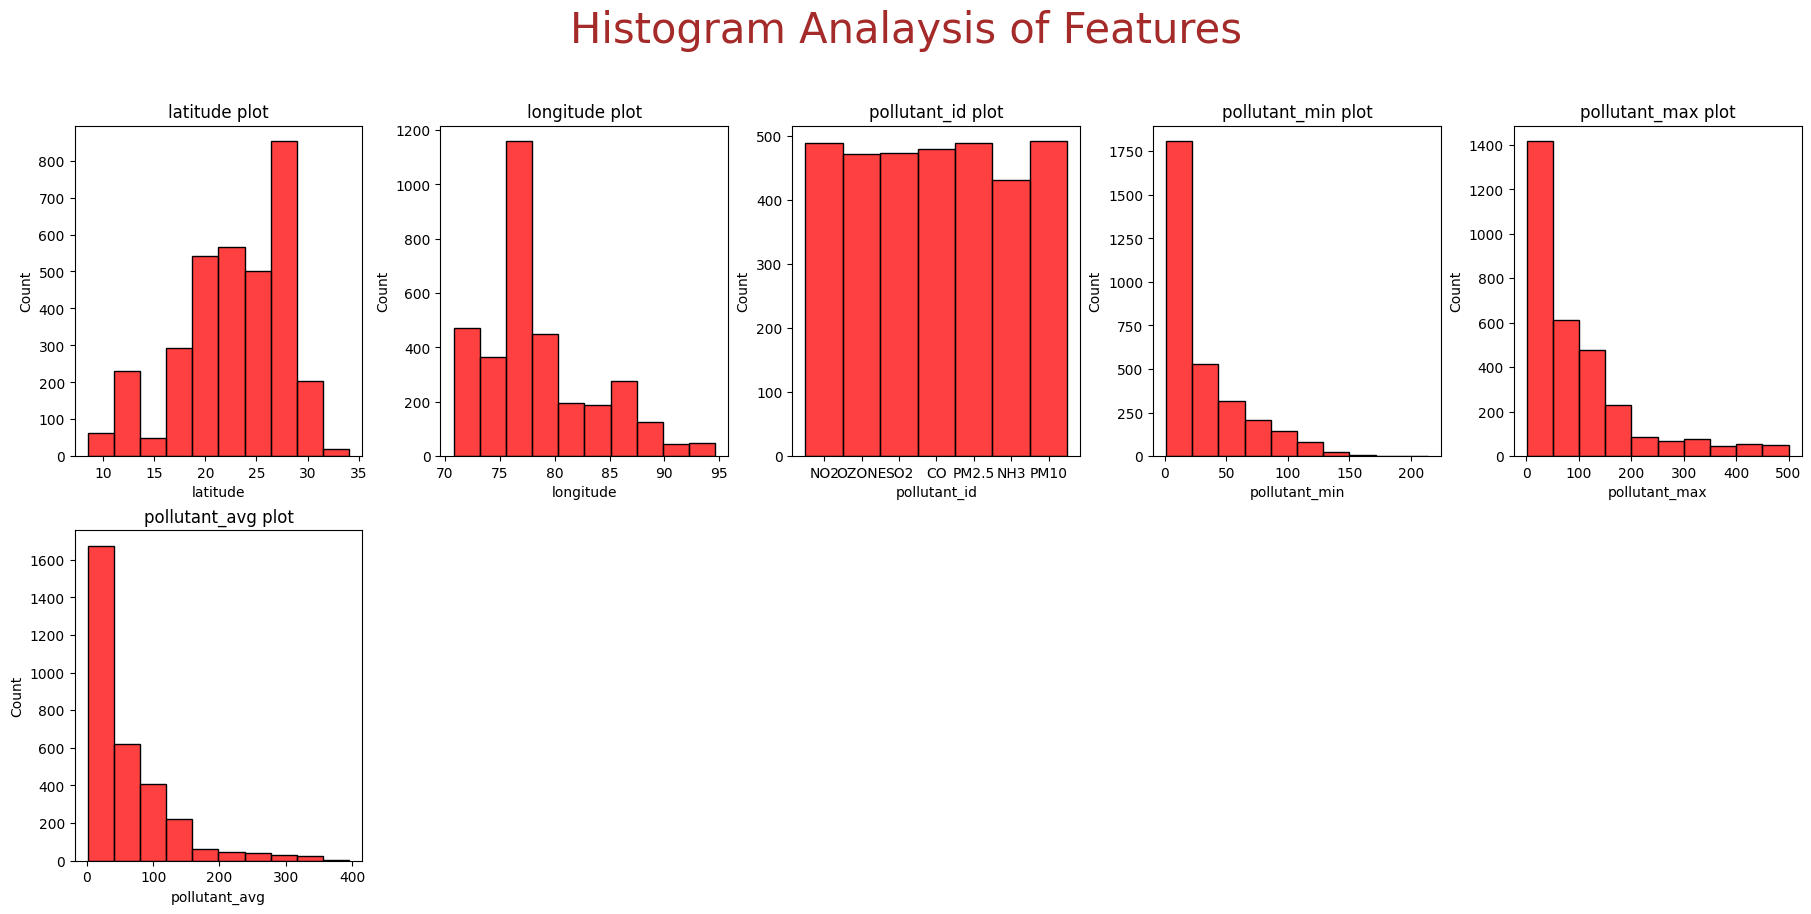

In [20]:
col=[ 'latitude',
       'longitude', 'pollutant_id', 'pollutant_min', 'pollutant_max',
       'pollutant_avg']
plt.figure(figsize=(18,18),layout="constrained")
plt.suptitle("Histogram Analaysis of Features",color="Brown",fontsize=30,y=1.05)
for i in range(len(col)):
    plt.subplot(5,5,i+1)
    sns.histplot(data=data,bins=10,x=data[col[i]],color="red",edgecolor="black")
    plt.title(col[i]+" plot")

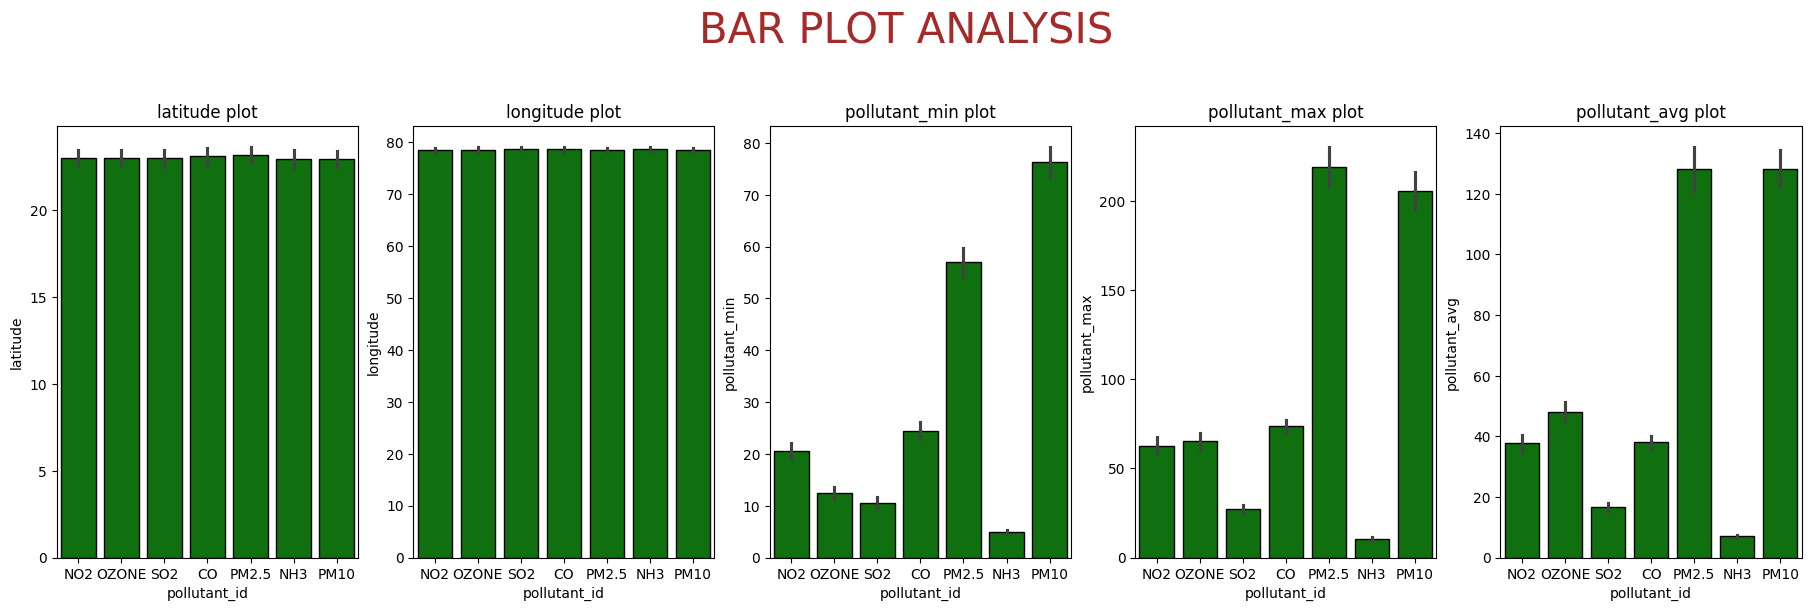

In [21]:
col=[ 'latitude',
       'longitude', 'pollutant_min', 'pollutant_max',
       'pollutant_avg']
plt.figure(figsize=(18,18),layout="constrained")
plt.suptitle("BAR PLOT ANALYSIS",color="Brown",fontsize=30,y=1.05)
for i in range(len(col)):
    plt.subplot(4,5,i+1)
    sns.barplot(data=data,x=data['pollutant_id'],y=data[col[i]],color="green",edgecolor="black")
    plt.title(col[i]+" plot")

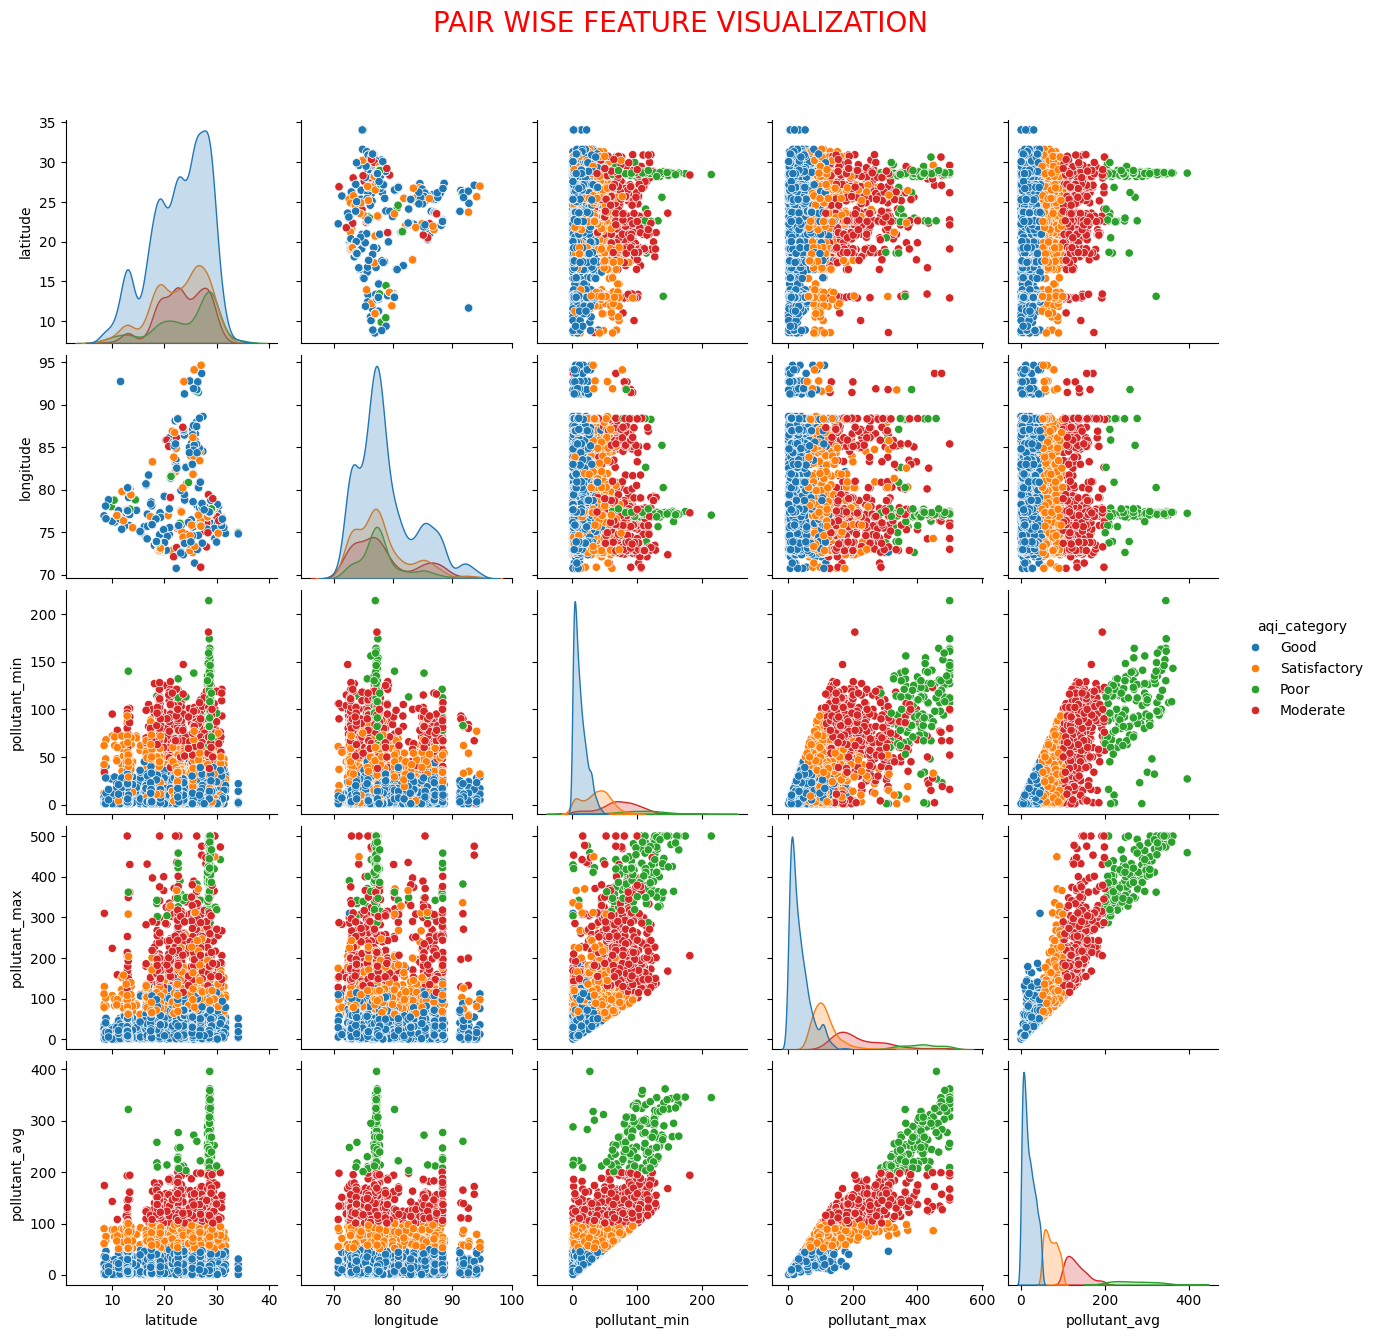

In [22]:
cl = ['latitude','longitude','pollutant_min','pollutant_max','pollutant_avg','aqi_category']
sns.pairplot(data[cl],hue="aqi_category")
plt.suptitle("PAIR WISE FEATURE VISUALIZATION",color="red",fontsize=20,y=1.07)
plt.show()

# DETECTING AND TREATING OF OUTLIERS

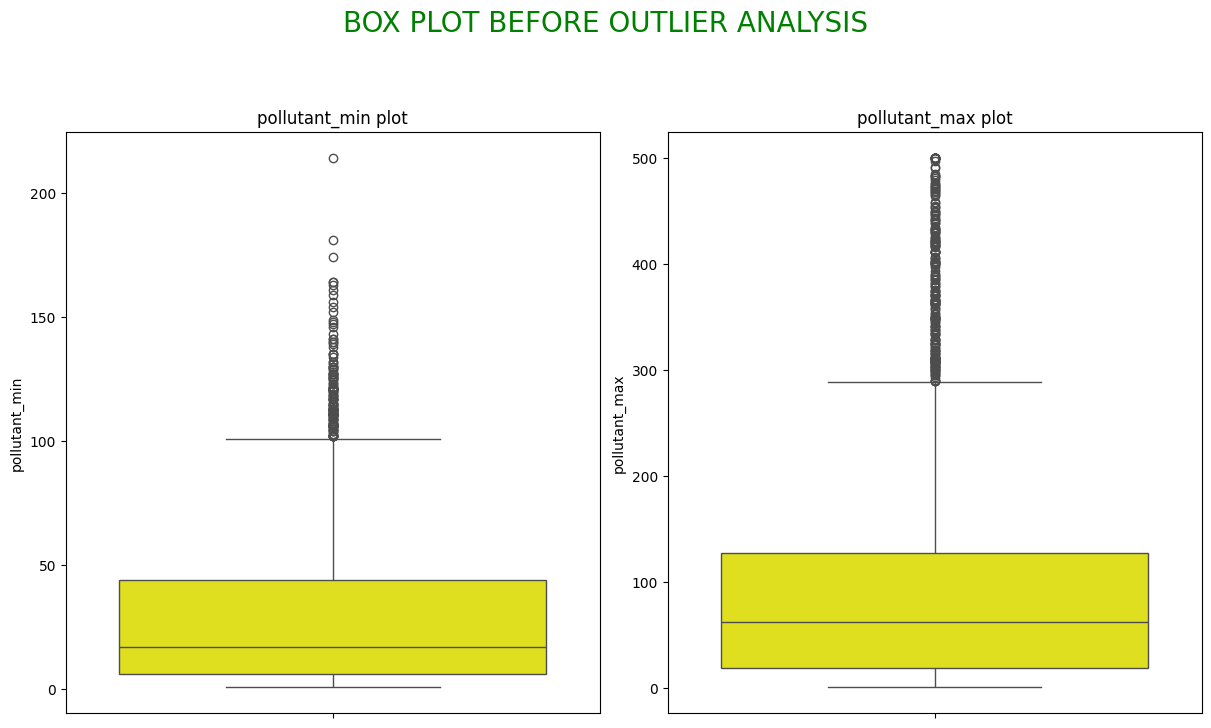

In [23]:
col=['pollutant_min','pollutant_max']
plt.figure(figsize=(12,12),layout='constrained')
plt.suptitle('BOX PLOT BEFORE OUTLIER ANALYSIS',color='green',fontsize=20,y=1.08)
for i in range(len(col)):
    plt.subplot(2,2,i+1)
    sns.boxplot(data[col[i]],color='yellow')
    plt.title(col[i]+ " plot")

## OUTLIER TREATING CAPPING METHOD

In [24]:
for i in col:
    Q1=data[i].quantile(0.25)
    Q3=data[i].quantile(0.75)
    IQR= Q3-Q1

    lower=Q1 - 1.5 * IQR
    upper=Q3 + 1.5 * IQR

    data[i] = data[i].clip(lower,upper)

#clip() = limit values within a range

#It forces all values to stay between:
#lower limit
#upper limit


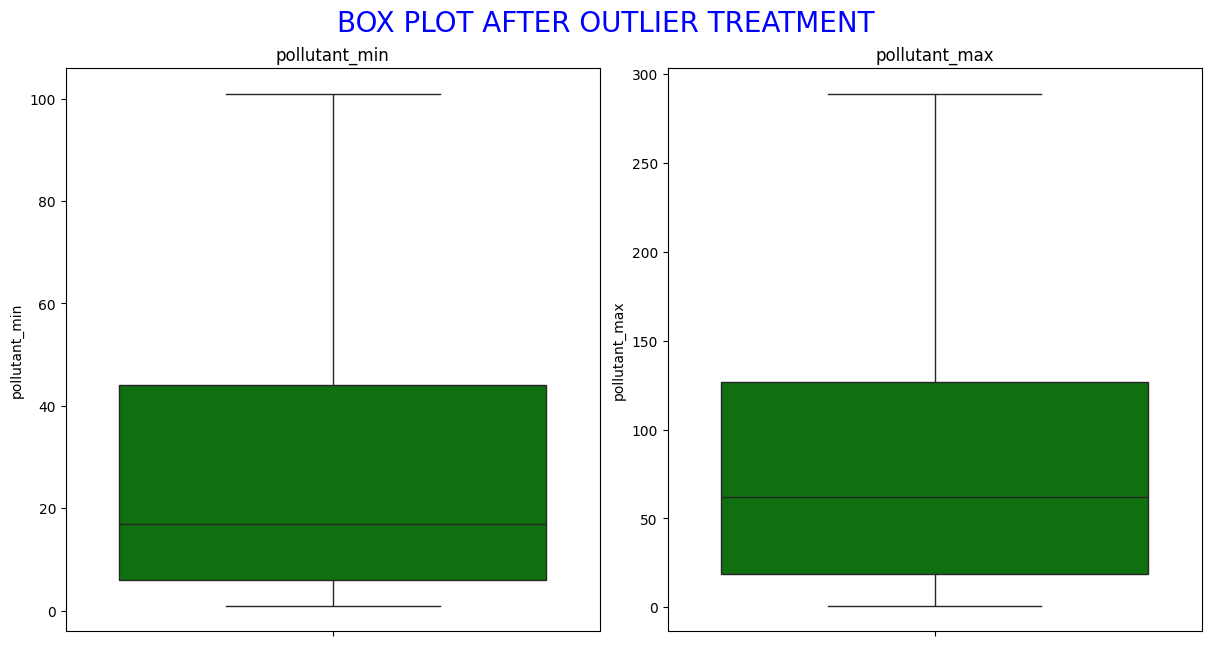

In [25]:
plt.figure(figsize=(12,12), layout='constrained')
plt.suptitle('BOX PLOT AFTER OUTLIER TREATMENT', color='blue', fontsize=20)

for i in range(len(col)):
    plt.subplot(2,2,i+1)
    sns.boxplot(data[col[i]], color='green')
    plt.title(col[i])

plt.show()

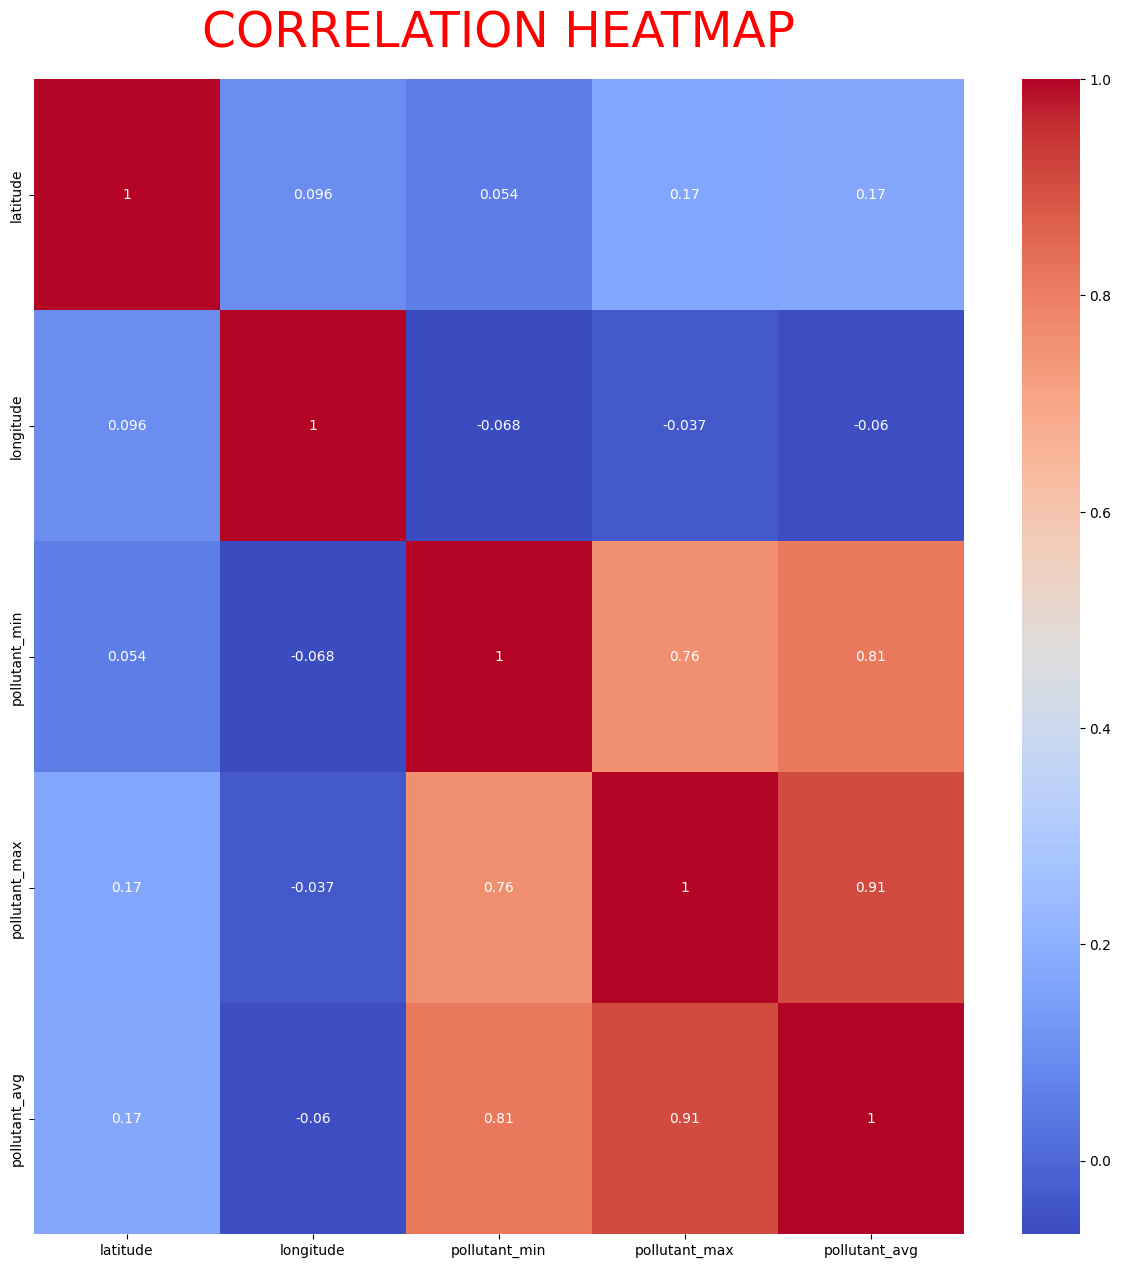

In [26]:
plt.figure(figsize=(15,15))
plt.title('CORRELATION HEATMAP',color="red",fontsize=35,y=1.02)
sns.heatmap(data.select_dtypes(include="number").corr(),annot=True,cmap="coolwarm")
plt.show()

In [27]:
print(data['pollutant_avg'].max())
print(data['pollutant_avg'].describe())

396.0
count    3122.000000
mean       58.470852
std        63.607334
min         1.000000
25%        13.000000
50%        36.000000
75%        84.000000
max       396.000000
Name: pollutant_avg, dtype: float64


In [28]:
data.isna().sum()

country            0
state              0
city               0
station            0
last_update        0
latitude           0
longitude          0
pollutant_id       0
pollutant_min    200
pollutant_max    200
pollutant_avg    200
aqi_category       0
dtype: int64

In [29]:
data=data.drop(['last_update','country','station'],axis=1)
#1. country Only one value = (India No useful information)
#2. station High cardinality (many unique values) Acts like an ID, not useful for prediction
#3. last_update Date/time column Not directly useful unless you do time-series

# MAPPING

In [30]:
mapping={
    'Good':0,
    'Satisfactory':1,
    'Moderate':2,
    'Poor':3
}
data['aqi_category']=data['aqi_category'].map(mapping)
print(data['aqi_category'].value_counts())

aqi_category
0    1860
1     658
2     466
3     338
Name: count, dtype: int64


# PREPROCESSING

# DATA MODELING¶

In [31]:
x=data.drop(['aqi_category'],axis=1)
y=data['aqi_category']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.3,random_state=42)

# ENCODING

In [32]:
ohe_state=OneHotEncoder(handle_unknown='ignore',sparse_output=False)
ohe_city=OneHotEncoder(handle_unknown="ignore",sparse_output=False)
ohe_pollutant_id=OneHotEncoder(handle_unknown='ignore',sparse_output=False) 

#FITTING AND TRANSFORMING ON TRAINING DATA

state_train = ohe_state.fit_transform(x_train[['state']])
city_train = ohe_city.fit_transform(x_train[['city']])
pollutant_train = ohe_pollutant_id.fit_transform(x_train[['pollutant_id']])

#ONLY TRANSFORMING THE TESTING DATA BECAUSE OF THE DATA LEAKAGE

state_test = ohe_state.transform(x_test[['state']])
city_test = ohe_city.transform(x_test[['city']])
pollutant_test = ohe_pollutant_id.transform(x_test[['pollutant_id']])





## SCALING

In [33]:
num_cols=['latitude','longitude','pollutant_min','pollutant_max','pollutant_avg']

num_train = x_train[num_cols]
num_test = x_test[num_cols]

scaler = StandardScaler()

#SCALING THE DATA

num_train_scaled = scaler.fit_transform(num_train)
num_test_scaled = scaler.transform(num_test)

#SCALED DATA FOR THE ALGORITHM LIKE LINEARREGRESSION,KNN

x_train_scaled=np.concatenate(
    [num_train_scaled,state_train,city_train,pollutant_train],
    axis=1)

x_test_scaled=np.concatenate(
    [num_test_scaled,state_test,city_test,pollutant_test],
    axis=1)

#UNSCALED DATA FOR THE ALGORITHM LIKE DESCISION TREE
x_train_unscaled=np.concatenate(
    [num_train.values,state_train,city_train,pollutant_train],
    axis=1)

x_test_unscaled=np.concatenate(
    [num_test.values,state_test,city_test,pollutant_test],
    axis=1)




In [34]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')

#FITTING AND TRANSFORMING FOR BOTH SCALED AND UNSCALED DATA

x_train_scaled=imputer.fit_transform(x_train_scaled)
x_test_scaled=imputer.fit_transform(x_test_scaled)

x_train_unscaled=imputer.fit_transform(x_train_unscaled)
x_test_unscaled=imputer.fit_transform(x_test_unscaled)

# OVERSAMPLING USING SMOTE

In [35]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_scaled_res,y_train_scaled_res=smote.fit_resample(x_train_scaled,y_train)
x_train_unscaled_res,y_train_unscaled_res=smote.fit_resample(x_train_unscaled,y_train)

In [36]:
#Apllying scaled data for scale-sensitive models 
#like logisticregression,svm,knn,and used smote in  all datas to handle class imbalance

In [37]:
pd.Series(y_train).value_counts()


aqi_category
0    1290
1     473
2     326
3     236
Name: count, dtype: int64

# MODEL FITTING
Training multiple machine learning models and optimize performence through systematic evaluation and validation

## LOGISTIC REGRESSION

In [38]:
lr = LogisticRegression(C=0.1, class_weight='balanced')
lr.fit(x_train_scaled_res,y_train_scaled_res)

y_train_pred_lr = lr.predict(x_train_scaled_res)
y_test_pred_lr = lr.predict(x_test_scaled)

lr_train = accuracy_score(y_train_scaled_res, y_train_pred_lr)
lr_test = accuracy_score(y_test, y_test_pred_lr)
cm = confusion_matrix(y_test, y_test_pred_lr)
cs = classification_report(y_test, y_test_pred_lr)

print("Train score:", lr_train)
print("Test score:", lr_test)
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", cs)

Train score: 0.853875968992248
Test score: 0.8284854563691073
Confusion Matrix:
 [[509  38   2  21]
 [  3 141  19  22]
 [  0  14 117   9]
 [ 18  10  15  59]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.89      0.93       570
           1       0.69      0.76      0.73       185
           2       0.76      0.84      0.80       140
           3       0.53      0.58      0.55       102

    accuracy                           0.83       997
   macro avg       0.74      0.77      0.75       997
weighted avg       0.84      0.83      0.83       997



## KNEIGHBORS CLASSIFIER (KNN)

In [39]:
knn=KNeighborsClassifier(n_neighbors=20,weights='uniform')
knn.fit(x_train_scaled_res,y_train_scaled_res)

y_train_pred_knn=knn.predict(x_train_scaled_res)
y_test_pred_knn=knn.predict(x_test_scaled)

knn_train=accuracy_score(y_train_scaled_res,y_train_pred_knn)
knn_test=accuracy_score(y_test,y_test_pred_knn)
cm=confusion_matrix(y_test,y_test_pred_knn)
cs=classification_report(y_test,y_test_pred_knn)

print("train accuracy:\n",knn_train)
print("test accuracy:\n",knn_test)
print("confusion matrix:\n",cm)
print("classification report:\n",cs)

train accuracy:
 0.8994186046511627
test accuracy:
 0.765295887662989
confusion matrix:
 [[419  44   0 107]
 [  9 133  16  27]
 [  0  13 124   3]
 [  8   2   5  87]]
classification report:
               precision    recall  f1-score   support

           0       0.96      0.74      0.83       570
           1       0.69      0.72      0.71       185
           2       0.86      0.89      0.87       140
           3       0.39      0.85      0.53       102

    accuracy                           0.77       997
   macro avg       0.72      0.80      0.74       997
weighted avg       0.84      0.77      0.78       997



# SUPPORT VECTOR MACHINE(SVM)

## SIGMOID

In [40]:
smodels=SVC(kernel="sigmoid",class_weight="balanced")
smodels.fit(x_train_scaled_res,y_train_scaled_res)

y_train_pred_ss=smodels.predict(x_train_scaled_res)
y_test_pred_ss=smodels.predict(x_test_scaled)

ss_train=accuracy_score(y_train_scaled_res,y_train_pred_ss) 
ss_test=accuracy_score(y_test,y_test_pred_ss) 
cm=confusion_matrix(y_test,y_test_pred_ss)
cs=classification_report(y_test,y_test_pred_ss)

print("train score:",ss_train) 
print("test score:",ss_test)
print('confusion matrix:\n',cm) 
print("classification report:\n",cs)

train score: 0.3577519379844961
test score: 0.5997993981945837
confusion matrix:
 [[538  11   0  21]
 [  5  18   0 162]
 [  0   2  41  97]
 [ 59   0  42   1]]
classification report:
               precision    recall  f1-score   support

           0       0.89      0.94      0.92       570
           1       0.58      0.10      0.17       185
           2       0.49      0.29      0.37       140
           3       0.00      0.01      0.01       102

    accuracy                           0.60       997
   macro avg       0.49      0.34      0.36       997
weighted avg       0.69      0.60      0.61       997



## RBF (RADIAL BASIS FUNCTION)

In [41]:
smodelr=SVC(kernel="rbf",class_weight="balanced",C=0.1)
smodelr.fit(x_train_scaled_res,y_train_scaled_res)

y_train_pred_sr=smodelr.predict(x_train_scaled_res)
y_test_pred_sr=smodelr.predict(x_test_scaled)

sr_train=accuracy_score(y_train_scaled_res,y_train_pred_sr)
sr_test=accuracy_score(y_test,y_test_pred_sr)
cm=confusion_matrix(y_test,y_test_pred_sr)
cs=classification_report(y_test,y_test_pred_sr)

print("train score:",sr_train)
print("test score:",sr_test)
print("confusion matric:\n",cm)
print("classification report:\n",cs)

train score: 0.9430232558139535
test score: 0.892678034102307
confusion matric:
 [[512  25   0  33]
 [  5 161  10   9]
 [  0   8 131   1]
 [ 13   0   3  86]]
classification report:
               precision    recall  f1-score   support

           0       0.97      0.90      0.93       570
           1       0.83      0.87      0.85       185
           2       0.91      0.94      0.92       140
           3       0.67      0.84      0.74       102

    accuracy                           0.89       997
   macro avg       0.84      0.89      0.86       997
weighted avg       0.90      0.89      0.90       997



## POLY

In [42]:
smodelp=SVC(kernel="poly",C=0.1,gamma='scale')
smodelp.fit(x_train_scaled_res,y_train_scaled_res)

y_train_pred_sp=smodelp.predict(x_train_scaled_res)
y_test_pred_sp=smodelp.predict(x_test_scaled)

sp_train=accuracy_score(y_train_scaled_res,y_train_pred_sp)
sp_test=accuracy_score(y_test,y_test_pred_sp)
cm=confusion_matrix(y_test,y_test_pred_sp)
cs=classification_report(y_test,y_test_pred_sp)

print("train score:",sp_train)
print("test score:",sp_test)

print("confusion matrix:\n",cm)
print("classification report:\n",cs)


train score: 0.7957364341085271
test score: 0.794383149448345
confusion matrix:
 [[460 108   0   2]
 [  2 174   7   2]
 [  0  20 118   2]
 [ 31  24   7  40]]
classification report:
               precision    recall  f1-score   support

           0       0.93      0.81      0.87       570
           1       0.53      0.94      0.68       185
           2       0.89      0.84      0.87       140
           3       0.87      0.39      0.54       102

    accuracy                           0.79       997
   macro avg       0.81      0.75      0.74       997
weighted avg       0.85      0.79      0.80       997



# DECISION TREE

In [43]:
dt=DecisionTreeClassifier(max_depth=8,min_samples_leaf=15,random_state=42)
dt.fit(x_train_unscaled_res,y_train_unscaled_res)

y_train_pred_dt=dt.predict(x_train_unscaled_res)
y_test_pred_dt=dt.predict(x_test_unscaled)


dt_train=accuracy_score(y_train_unscaled_res,y_train_pred_dt)
dt_test=accuracy_score(y_test,y_test_pred_dt)

cm=confusion_matrix(y_test,y_test_pred_dt)
cs=classification_report(y_test,y_test_pred_dt)

print("train score:",dt_train)
print("test score:",dt_test)

print("confusion matrix:",cm)
print("classifical report",cs)

train score: 0.9978682170542635
test score: 0.9368104312938816
confusion matrix: [[566   0   0   4]
 [  0 185   0   0]
 [  0   0 140   0]
 [ 59   0   0  43]]
classifical report               precision    recall  f1-score   support

           0       0.91      0.99      0.95       570
           1       1.00      1.00      1.00       185
           2       1.00      1.00      1.00       140
           3       0.91      0.42      0.58       102

    accuracy                           0.94       997
   macro avg       0.96      0.85      0.88       997
weighted avg       0.94      0.94      0.93       997



# RANDOM FOREST

In [44]:
rf=RandomForestClassifier(n_estimators=300,max_depth=8,random_state=42)
rf.fit(x_train_unscaled_res,y_train_unscaled_res)

y_train_pred_rf=rf.predict(x_train_unscaled_res)
y_test_pred_rf=rf.predict(x_test_unscaled)

rf_train=accuracy_score(y_train_unscaled_res,y_train_pred_rf)
rf_test=accuracy_score(y_test,y_test_pred_rf)
cm=confusion_matrix(y_test,y_test_pred_rf)
cs=classification_report(y_test,y_test_pred_rf)

print("train score:",rf_train)
print("test score:",rf_test)
print("confusion matrix",cm)
print("classification report:",cs)


train score: 0.9784883720930233
test score: 0.9027081243731193
confusion matrix [[554  15   0   1]
 [  0 183   2   0]
 [  0   1 138   1]
 [ 59   0  18  25]]
classification report:               precision    recall  f1-score   support

           0       0.90      0.97      0.94       570
           1       0.92      0.99      0.95       185
           2       0.87      0.99      0.93       140
           3       0.93      0.25      0.39       102

    accuracy                           0.90       997
   macro avg       0.91      0.80      0.80       997
weighted avg       0.90      0.90      0.88       997



# ADABOOSTER

In [45]:
ab=AdaBoostClassifier(n_estimators=200,learning_rate=0.02)
ab.fit(x_train_unscaled_res,y_train_unscaled_res)

y_train_pred_ab=ab.predict(x_train_unscaled_res)
y_test_pred_ab=ab.predict(x_test_unscaled)

ab_train=accuracy_score(y_train_unscaled_res,y_train_pred_ab)
ab_test=accuracy_score(y_test,y_test_pred_ab)
cm=confusion_matrix(y_test,y_test_pred_ab)
cs=classification_report(y_test,y_test_pred_ab)

print("train_accuracy score ",ab_train)
print("test_accuracy score ",ab_test)

print("confusion_matrix",cm)
print("classification_report",cs)

train_accuracy score  0.8751937984496124
test_accuracy score  0.8485456369107321
confusion_matrix [[521   0   0  49]
 [  0 185   0   0]
 [  0   0 140   0]
 [ 59   0  43   0]]
classification_report               precision    recall  f1-score   support

           0       0.90      0.91      0.91       570
           1       1.00      1.00      1.00       185
           2       0.77      1.00      0.87       140
           3       0.00      0.00      0.00       102

    accuracy                           0.85       997
   macro avg       0.67      0.73      0.69       997
weighted avg       0.81      0.85      0.83       997



# GRADIENTBOOSTING

In [46]:
gb=GradientBoostingClassifier(n_estimators=100,max_depth=3,subsample=.08,learning_rate=0.1,random_state=42)
gb.fit(x_train_unscaled_res,y_train_unscaled_res)

y_train_pred_gb=gb.predict(x_train_unscaled_res)
y_test_pred_gb=gb.predict(x_test_unscaled)

gb_train=accuracy_score(y_train_unscaled_res,y_train_pred_gb) 
gb_test=accuracy_score(y_test,y_test_pred_gb)
cm=confusion_matrix(y_test,y_test_pred_gb)
cs=classification_report(y_test,y_test_pred_gb)

print("train_accuracy score ",gb_train)
print("test_accuracy score ",gb_test)

print("confusion_matrix\n",cm)
print("classification_report\n",cs)

train_accuracy score  1.0
test_accuracy score  0.9348044132397192
confusion_matrix
 [[566   0   0   4]
 [  0 185   0   0]
 [  0   0 140   0]
 [ 59   0   2  41]]
classification_report
               precision    recall  f1-score   support

           0       0.91      0.99      0.95       570
           1       1.00      1.00      1.00       185
           2       0.99      1.00      0.99       140
           3       0.91      0.40      0.56       102

    accuracy                           0.93       997
   macro avg       0.95      0.85      0.87       997
weighted avg       0.93      0.93      0.92       997



# XGBOOSTING

In [47]:
xg=XGBClassifier(n_estimators=600,learning_rate=0.1,max_depth=3,subsample=0.8)
xg.fit(x_train_unscaled_res,y_train_unscaled_res)

y_train_pred_xg=xg.predict(x_train_unscaled_res)
y_test_pred_xg=xg.predict(x_test_unscaled)

xg_train=accuracy_score(y_train_unscaled_res,y_train_pred_xg)
xg_test=accuracy_score(y_test,y_test_pred_xg)
cm=confusion_matrix(y_test,y_test_pred_xg)
cs=classification_report(y_test,y_test_pred_xg)

print("train_accuracy score",xg_train)
print("test_accuracy score:",xg_test)

print("confusion_matrix\n",cm)
print("classification_report\n",cs)

train_accuracy score 1.0
test_accuracy score: 0.9317953861584755
confusion_matrix
 [[569   0   0   1]
 [  0 184   1   0]
 [  0   6 133   1]
 [ 59   0   0  43]]
classification_report
               precision    recall  f1-score   support

           0       0.91      1.00      0.95       570
           1       0.97      0.99      0.98       185
           2       0.99      0.95      0.97       140
           3       0.96      0.42      0.59       102

    accuracy                           0.93       997
   macro avg       0.96      0.84      0.87       997
weighted avg       0.93      0.93      0.92       997



# NAIVE BAYES

In [48]:
nb=GaussianNB(var_smoothing=1e-2)
nb.fit(x_train_unscaled_res,y_train_unscaled_res)

y_train_pred_nb=nb.predict(x_train_unscaled_res)
y_test_pred_nb=nb.predict(x_test_unscaled)


nb_train=accuracy_score(y_train_unscaled_res,y_train_pred_nb)
nb_test=accuracy_score(y_test,y_test_pred_nb)
cm=confusion_matrix(y_test,y_test_pred_nb)
cs=classification_report(y_test,y_test_pred_nb)

print("train score:",nb_train)
print("test score:",nb_test)
print("confusion matrix:\n",cm)
print("classification report:\n",cs)
      
      

                       

train score: 0.796124031007752
test score: 0.8706118355065195
confusion matrix:
 [[535  32   0   3]
 [  6 168   9   2]
 [  0  10 122   8]
 [ 59   0   0  43]]
classification report:
               precision    recall  f1-score   support

           0       0.89      0.94      0.91       570
           1       0.80      0.91      0.85       185
           2       0.93      0.87      0.90       140
           3       0.77      0.42      0.54       102

    accuracy                           0.87       997
   macro avg       0.85      0.78      0.80       997
weighted avg       0.87      0.87      0.86       997



In [49]:
tr_scores=[lr_train,knn_train,ss_train,sr_train,sp_train,
           dt_train,rf_train,ab_train,gb_train,xg_train,nb_train]

ts_scores=[lr_test,knn_test,ss_test,sr_test,sp_test,dt_test,
           rf_test,ab_test,gb_test,xg_test,nb_test]

models=["Logistic Regression","K Neighbors","SVM(sigmoid)","SVM(rbf)",
        "SVM(poly)","DecisionTree","RandomForest","Ada Booster","Gradient Booster",
        "XGBooster","GaussianNB"]
first_scores=pd.DataFrame({"Models":models,"Train Accuracy Score":tr_scores,
                           "Test Accuracy Score":ts_scores})

first_scores

,Models,Train Accuracy Score,Test Accuracy Score
0,Logistic Regression,0.853876,0.828485
1,K Neighbors,0.899419,0.765296
2,SVM(sigmoid),0.357752,0.599799
3,SVM(rbf),0.943023,0.892678
4,SVM(poly),0.795736,0.794383
5,DecisionTree,0.997868,0.936810
6,RandomForest,0.978488,0.902708
7,Ada Booster,0.875194,0.848546
8,Gradient Booster,1.000000,0.934804
9,XGBooster,1.000000,0.931795


# STRATIFIEDKFOLD CROSS VALIDATION
using stratified kfold cross validation to evaluate the best performing model

Preprocessing can be reused only when the data split is fixed, but when the data split changes, 
as in cross-validation, 
preprocessing must be recomputed every time to maintain correctness and avoid leakage.

In [50]:
from sklearn.model_selection import StratifiedKFold

In [51]:
fold=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [52]:
def getscore(model,x_train,x_test,y_train,y_test):
    model.fit(x_train,y_train)
    return model.score(x_test,y_test)
    

In [53]:
scores = {
    "Logistic Regression": [],
    "KNN": [],
    "SVM(sigmoid)": [],
    "SVM(rbf)": [],
    "SVM(poly)":[],
    "Decision Tree": [],
    "Random Forest": [],
    "adaboost":[],
    "Gradient Boosting": [],
    "XGBoost": [],
    "Naive Bayes": []
}


In [54]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder


for train_idx,test_idx in fold.split(x,y):
    x_train,x_test=x.loc[train_idx],x.loc[test_idx]
    y_train,y_test=y.loc[train_idx],y.loc[test_idx]

    num_train = x_train[num_cols]
    num_test = x_test[num_cols]

    
    ohe=OneHotEncoder(handle_unknown='ignore',sparse_output=False)
    cat_train=ohe.fit_transform(x_train[['state','city','pollutant_id']])
    cat_test=ohe.transform(x_test[['state','city','pollutant_id']])

    scaler=StandardScaler()
    num_train_scaled=scaler.fit_transform(num_train)
    num_test_scaled=scaler.transform(num_test)

    x_train_scaled=np.concatenate([num_train_scaled,cat_train],axis=1)
    x_test_scaled=np.concatenate([num_test_scaled,cat_test],axis=1)
    x_train_unscaled=np.concatenate([num_train.values,cat_train],axis=1)
    x_test_unscaled=np.concatenate([num_test.values,cat_test],axis=1)

    imputer=SimpleImputer(strategy='median')
    x_train_scaled=imputer.fit_transform(x_train_scaled)
    x_test_scaled=imputer.transform(x_test_scaled)
    x_train_unscaled=imputer.fit_transform(x_train_unscaled)
    x_test_unscaled=imputer.transform(x_test_unscaled)

    smote=SMOTE(random_state=42)
    x_train_scaled_res,y_train_scaled_res=smote.fit_resample(x_train_scaled,y_train)
    x_train_unscaled_res,y_train_unscaled_res=smote.fit_resample(x_train_unscaled,y_train)

    
    scores["Logistic Regression"].append(
        getscore(LogisticRegression(C=0.1),x_train_scaled_res,
                 x_test_scaled,y_train_scaled_res, y_test))
    
    scores["KNN"].append(getscore(
        KNeighborsClassifier(n_neighbors=10),x_train_scaled_res,
        x_test_scaled,y_train_scaled_res,y_test))

    scores["SVM(sigmoid)"].append(getscore(
        SVC(kernel="sigmoid",class_weight="balanced"),x_train_scaled_res,
        x_test_scaled,y_train_scaled_res,y_test))

    scores["SVM(rbf)"].append(getscore(
        SVC(kernel="rbf",class_weight="balanced"),x_train_scaled_res,
        x_test_scaled,y_train_scaled_res,y_test))

    scores["SVM(poly)"].append(getscore(
        SVC(kernel="poly",C=0.1,gamma="scale"),x_train_scaled_res,
        x_test_scaled,y_train_scaled_res,y_test))

    scores["Decision Tree"].append(getscore(
        DecisionTreeClassifier(max_depth=3,random_state=42,class_weight='balanced'),
        x_train_unscaled_res,x_test_unscaled,y_train_unscaled_res,y_test))

    scores["Random Forest"].append(getscore(
        RandomForestClassifier(n_estimators=200,random_state=42,class_weight="balanced",max_depth=6),
        x_train_unscaled_res,x_test_unscaled,y_train_unscaled_res,y_test))

    scores["adaboost"].append(getscore(
        AdaBoostClassifier(n_estimators=100),x_train_unscaled_res,x_test_unscaled,
        y_train_unscaled_res,y_test))

    scores["Gradient Boosting"].append(getscore(
        GradientBoostingClassifier(n_estimators=200,max_depth=5),
        x_train_unscaled_res,x_test_unscaled,y_train_unscaled_res,y_test))

    scores["XGBoost"].append(getscore(
        XGBClassifier(n_estimators=200,max_depth=3,scale_pos_weight=3),
        x_train_unscaled_res,x_test_unscaled,y_train_unscaled_res,y_test))

    scores["Naive Bayes"].append(getscore(
        GaussianNB(),x_train_unscaled_res,x_test_unscaled,y_train_unscaled_res,
        y_test))

  

In [55]:
l=np.mean(scores["Logistic Regression"])
k=np.mean(scores["KNN"])
svms=np.mean(scores["SVM(sigmoid)"])
svmr=np.mean(scores["SVM(rbf)"])
svmp=np.mean(scores["SVM(poly)"])
d=np.mean(scores["Decision Tree"])
r=np.mean(scores["Random Forest"])
a=np.mean(scores["adaboost"])
gb=np.mean(scores["Gradient Boosting"])
xg=np.mean(scores["XGBoost"])
gs=np.mean(scores["Naive Bayes"])

In [56]:
first_scores['scores after crosss validation']=[l,k,svms,svmr,svmp,d,r,a,gb,xg,gs]

In [57]:
first_scores

,Models,Train Accuracy Score,Test Accuracy Score,scores after crosss validation
0,Logistic Regression,0.853876,0.828485,0.834736
1,K Neighbors,0.899419,0.765296,0.812453
2,SVM(sigmoid),0.357752,0.599799,0.606560
3,SVM(rbf),0.943023,0.892678,0.923534
4,SVM(poly),0.795736,0.794383,0.798910
5,DecisionTree,0.997868,0.936810,0.906381
6,RandomForest,0.978488,0.902708,0.930458
7,Ada Booster,0.875194,0.848546,0.925982
8,Gradient Booster,1.000000,0.934804,0.999699
9,XGBooster,1.000000,0.931795,0.996689


# HYPER-TUNING

Hyper tuning the best 4 algorithm from the analyzed data to find the best parameter for the model

In [58]:
from sklearn.model_selection import GridSearchCV

In [59]:
xgb_params={
    'n_estimators':[100,200],
    'max_depth':[3,5],
    'learning_rate':[0.01,0.1],
    'gamma':[0,0.1]
}
xgb_grid=GridSearchCV(
    XGBClassifier(random_state=42),xgb_params,cv=5,scoring='accuracy',n_jobs=-1,verbose=1)
xgb_grid.fit(x_train_unscaled_res,y_train_unscaled_res)
print(xgb_grid.best_score_)
print(xgb_grid.best_params_)
    

Fitting 5 folds for each of 16 candidates, totalling 80 fits
0.9983205977605148
{'gamma': 0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}


In [60]:
svm_rbf_params={
     'kernel': ['rbf'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01]
}
svm_rbf_grid=GridSearchCV(
    SVC(),svm_rbf_params,cv=5,return_train_score=True,n_jobs=-1)
svm_rbf_grid.fit(x_train_scaled_res,y_train_scaled_res)
print(svm_rbf_grid.best_score_)
print(svm_rbf_grid.best_params_)
         

0.9840409513931517
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [61]:
ad_param={
    "n_estimators":[100,200],
    "learning_rate":[0.1,1.0],
    'algorithm'    : ['SAMME']
}
ad_grid=GridSearchCV(AdaBoostClassifier(random_state=42),ad_param,
                     cv=5,return_train_score=True,n_jobs=-1)
ad_grid.fit(x_train_unscaled_res,y_train_unscaled_res)
print(ad_grid.best_score_)
print(ad_grid.best_params_)  
          
              
    

0.9329682704315984
{'algorithm': 'SAMME', 'learning_rate': 1.0, 'n_estimators': 100}


In [62]:
gb_param={
    "n_estimators":[100,200],
    "learning_rate":[0.01,0.1],
    "max_depth":[3,5]
}
gb_grid=GridSearchCV(GradientBoostingClassifier(random_state=42),gb_param,
                     cv=5,return_train_score=True,n_jobs=-1)

gb_grid.fit(x_train_unscaled_res,y_train_unscaled_res)
print(gb_grid.best_score_)
print(gb_grid.best_params_)   

0.9998319327731092
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


In [63]:
rf_param={
    "n_estimators":[100,200],
    "max_depth":[6,8],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}
rf_grid=GridSearchCV(RandomForestClassifier(random_state=42),rf_param,
                     cv=5,scoring='accuracy',n_jobs=-1)
rf_grid.fit(x_train_unscaled_res,y_train_unscaled_res)
print(rf_grid.best_score_)
print(rf_grid.best_params_)


0.9630414382377637
{'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [64]:
svm_rbf_grid.best_estimator_

SVC(C=10)

# FINAL MODEL EVALUATION

In [65]:
best_model=svm_rbf_grid.best_estimator_
best_model.fit(x_train_scaled_res,y_train_scaled_res)

y_train_pred_sr=smodelr.predict(x_train_scaled_res)
y_test_pred_sr=smodelr.predict(x_test_scaled)

sr_train=accuracy_score(y_train_scaled_res,y_train_pred_sr)
sr_test=accuracy_score(y_test,y_test_pred_sr)
cm=confusion_matrix(y_test,y_test_pred_sr)
cs=classification_report(y_test,y_test_pred_sr)

print("train score:",sr_train)
print("test score:",sr_test)
print("confusion matric:\n",cm)
print("classification report:\n",cs)

train score: 0.9341397849462365
test score: 0.8975903614457831
confusion matric:
 [[331  16   0  25]
 [  4 118   7   2]
 [  0   5  88   0]
 [  8   0   1  59]]
classification report:
               precision    recall  f1-score   support

           0       0.97      0.89      0.93       372
           1       0.85      0.90      0.87       131
           2       0.92      0.95      0.93        93
           3       0.69      0.87      0.77        68

    accuracy                           0.90       664
   macro avg       0.85      0.90      0.87       664
weighted avg       0.91      0.90      0.90       664



In [66]:
train_columns=x_train.columns
train_columns

Index(['state', 'city', 'latitude', 'longitude', 'pollutant_id',
       'pollutant_min', 'pollutant_max', 'pollutant_avg'],
      dtype='object')

In [67]:
import joblib

In [68]:
import os
print(os.getcwd())

C:\Users\ABDULLA\PROJECT


In [75]:
joblib.dump(best_model,'best_model.pkl')
joblib.dump(ohe_state,'ohe_state.pkl')
joblib.dump(ohe_city,'ohe_city.pkl')
joblib.dump(ohe_pollutant_id,'ohe_pollutant_id.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(train_columns,'train_columns.pkl')


['train_columns.pkl']

In [ ]:
model=joblib.load('AQI_PROJECT/best_model.pkl')
scaler=joblib.load('AQI_PROJECT/scaler.pkl')
ohe_state=joblib.load('AQI_PROJECT/ohe_state.pkl')
ohe_city=joblib.load('AQI_PROJECT/ohe_city.pkl')
ohe_pollutant_id=joblib.load('AQI_PROJECT/ohe_pollutant_id.pkl')
train_columns=joblib.load('AQI_PROJECT/train_columns.pkl')

In [ ]:
def get_user_input():
    print("\nEnter AQI Prediction Details ")
    state         = input("Enter State (e.g. Kerala): ")
    city          = input("Enter City (e.g. Kochi): ")
    latitude      = float(input("Enter Latitude (e.g. 9.93): "))
    longitude     = float(input("Enter Longitude (e.g. 76.26): "))
    pollutant_id  = input("Enter Pollutant (e.g. NH3, PM2.5): ")  
    pollutant_min = float(input("Enter Pollutant Min (e.g. 20.0): "))   
    pollutant_max = float(input("Enter Pollutant Max (e.g. 80.0): "))
    pollutant_avg = float(input("Enter Pollutant Average (e.g. 45.2): "))
    return state, city, latitude, longitude, pollutant_id, \
           pollutant_min, pollutant_max , pollutant_avg                 

In [ ]:
def run_model():
    state, city, latitude, longitude, pollutant_id, \
    pollutant_min, pollutant_max, pollutant_avg = get_user_input()  
                                                                     

    state_val     = ohe_state.transform([[state]])
    city_val      = ohe_city.transform([[city]])
    pollutant_val = ohe_pollutant_id.transform([[pollutant_id]])

    num_val = scaler.transform([[latitude, longitude,
                                  pollutant_min,
                                  pollutant_max,
                                  pollutant_avg]])

    input_data = np.concatenate(
        [num_val, state_val, city_val, pollutant_val], axis=1)

    predict_num = model.predict(input_data)[0]

    if predict_num == 0:
        pred_category = 'Good'
        message       = ' Air Quality is Good!'
    elif predict_num == 1:
        pred_category = 'Satisfactory'
        message       = ' Air Quality is Satisfactory'
    elif predict_num == 2:
        pred_category = 'Moderate'
        message       = ' Air Quality is Moderate'
    elif predict_num == 3:
        pred_category = 'Poor'
        message       = ' Air Quality is Poor. Be Cautious!'
    elif predict_num == 4:
        pred_category = 'Very Poor'
        message       = ' Air Quality is Very Poor. Stay Indoors!'
    else:
        pred_category = 'Unknown'
        message       = '❓ Category Not Found'

    print("\n" + "="*40)
    print("       AQI PREDICTION RESULT")
    print("="*40)
    print(f"State         : {state}")
    print(f"City          : {city}")
    print(f"Latitude      : {latitude}")
    print(f"Longitude     : {longitude}")
    print(f"Pollutant     : {pollutant_id}")
    print(f"Pollutant min : {pollutant_min}")
    print(f"Pollutant Max : {pollutant_max}")
    print(f"Pollutant avg : {pollutant_avg}")
    print("="*40)
    print(f"Predicted AQI : {pred_category}")
    print(f"Message       : {message}")
    print("="*40)

run_model()
